In [1]:
from google.colab import files
carga = files.upload()

Saving results.csv to results (3).csv


In [2]:
import pandas as pd
df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49329 entries, 0 to 49328
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49329 non-null  object 
 1   home_team   49329 non-null  object 
 2   away_team   49329 non-null  object 
 3   home_score  49257 non-null  float64
 4   away_score  49257 non-null  float64
 5   tournament  49329 non-null  object 
 6   city        49329 non-null  object 
 7   country     49329 non-null  object 
 8   neutral     49329 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [4]:
#limpiamos los datos de home score y away score ya que tienen nulos
df = df.dropna(subset=["home_score", "away_score"])

In [5]:
#verificamos que ya esté limpio
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49257 entries, 0 to 49256
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49257 non-null  object 
 1   home_team   49257 non-null  object 
 2   away_team   49257 non-null  object 
 3   home_score  49257 non-null  float64
 4   away_score  49257 non-null  float64
 5   tournament  49257 non-null  object 
 6   city        49257 non-null  object 
 7   country     49257 non-null  object 
 8   neutral     49257 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.4+ MB


In [6]:
#convertimos los tipos de datos home score y away score a enteros, ya que son los goles de local y visitante
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

In [7]:
#verificamos los cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49257 entries, 0 to 49256
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49257 non-null  object
 1   home_team   49257 non-null  object
 2   away_team   49257 non-null  object
 3   home_score  49257 non-null  int64 
 4   away_score  49257 non-null  int64 
 5   tournament  49257 non-null  object
 6   city        49257 non-null  object
 7   country     49257 non-null  object
 8   neutral     49257 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.4+ MB


In [8]:
#vemos cuantos países se encuentran en la lista
#obtenemos todos los equipos que han jugado
teamsi = pd.unique(df[[
    'home_team',
    'away_team'
]].values.ravel())
len(teamsi)

336

In [9]:
#creamos el vector que obtendrá todos los equipos participantes
worldcup_teams = [
    "Canada", "Mexico", "United States", "Argentina", "Brazil",
    "Colombia", "Ecuador", "Paraguay", "Uruguay", "Austria",
    "Belgium", "Bosnia and Herzegovina", "Croatia", "Czech Republic", "England",
    "France", "Germany", "Netherlands", "Norway", "Portugal",
    "Scotland", "Spain", "Sweden", "Switzerland", "Turkey",
    "Algeria", "Cape Verde", "Congo DR", "Côte d'Ivoire", "Egypt",
    "Ghana", "Morocco", "Senegal", "South Africa", "Tunisia",
    "Australia", "Iran", "Iraq", "Japan", "Jordan",
    "South Korea","Qatar", "Saudi Arabia", "Uzbekistan", "Curaçao",
    "Haiti", "Panama", "New Zealand"
    ]

In [10]:
#normalizamos los nombres de los equipos
df["home_team"] = df["home_team"].replace({
    "DR Congo": "Congo DR",
    "Ivory Coast": "Côte d'Ivoire",
})

df["away_team"] = df["away_team"].replace({
    "DR Congo": "Congo DR",
    "Ivory Coast": "Côte d'Ivoire",
})

In [11]:
#definimos un campo donde nos guarde el ganador local, visitante o si fue empate
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return 0  # local gana
    elif row["home_score"] < row["away_score"]:
        return 2  # visitante gana
    else:
        return 1  # empate

df["target"] = df.apply(get_result, axis=1)

In [12]:
#filtramos los equipos pertenecientes al ranking de la FIFA
df_wc = df[
    df["home_team"].isin(worldcup_teams) &
    df["away_team"].isin(worldcup_teams)
].copy()

In [13]:
sorted(df_wc["home_team"].unique())

['Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Bosnia and Herzegovina',
 'Brazil',
 'Canada',
 'Cape Verde',
 'Colombia',
 'Congo DR',
 'Croatia',
 'Curaçao',
 'Czech Republic',
 "Côte d'Ivoire",
 'Ecuador',
 'Egypt',
 'England',
 'France',
 'Germany',
 'Ghana',
 'Haiti',
 'Iran',
 'Iraq',
 'Japan',
 'Jordan',
 'Mexico',
 'Morocco',
 'Netherlands',
 'New Zealand',
 'Norway',
 'Panama',
 'Paraguay',
 'Portugal',
 'Qatar',
 'Saudi Arabia',
 'Scotland',
 'Senegal',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Tunisia',
 'Turkey',
 'United States',
 'Uruguay',
 'Uzbekistan']

In [14]:
sorted(df_wc["away_team"].unique())

['Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Bosnia and Herzegovina',
 'Brazil',
 'Canada',
 'Cape Verde',
 'Colombia',
 'Congo DR',
 'Croatia',
 'Curaçao',
 'Czech Republic',
 "Côte d'Ivoire",
 'Ecuador',
 'Egypt',
 'England',
 'France',
 'Germany',
 'Ghana',
 'Haiti',
 'Iran',
 'Iraq',
 'Japan',
 'Jordan',
 'Mexico',
 'Morocco',
 'Netherlands',
 'New Zealand',
 'Norway',
 'Panama',
 'Paraguay',
 'Portugal',
 'Qatar',
 'Saudi Arabia',
 'Scotland',
 'Senegal',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Tunisia',
 'Turkey',
 'United States',
 'Uruguay',
 'Uzbekistan']

In [15]:
#verificamos la lista
df_wc.shape

(7501, 10)

In [16]:
df_wc["home_team"].nunique()

48

In [17]:
df_wc["away_team"].nunique()

48

In [18]:
#verificamos la creación de la columna
df_wc[["home_team",
    "home_score",
    "away_team",
    "away_score",
    "target"]].head()

,home_team,home_score,away_team,away_score,target
0,Scotland,0,England,0,1
1,England,4,Scotland,2,0
2,Scotland,2,England,1,0
3,England,2,Scotland,2,1
4,Scotland,3,England,0,0


In [19]:
#verificamos la cantidad de victorias por visitante, local y empates
df_wc["target"].value_counts()

,count
target,
0,3479
2,2124
1,1898


In [20]:
#verificamos la proporción de las victorias obtenidas en porcentaje
df_wc["target"].value_counts(normalize=True) * 100

,proportion
target,
0,46.380483
2,28.316225
1,25.303293


In [21]:
#calculamos las estadísticas por equipo
teams = pd.unique(df_wc[[
    'home_team',
    'away_team'
]].values.ravel())
len(teams)

#inicializamos un contenedor vacío.
team_stats = {}

#calculamos las estadísticas por equipo
for team in teams:

  #calculamos cuando juega en local y cuando en visitante
  home = df_wc[df_wc["home_team"] == team]
  away = df_wc[df_wc["away_team"] == team]

  #calculamos las victorias que tuvo el equipo
  wins = (
      (home["home_score"]> home["away_score"]).sum()+
      (away["away_score"]>away["home_score"]).sum()
  )

  #caluclamos cuantos partidos jugó el equipo.
  matches = len(home)+len(away)

  #obtenemos la cantidad de coles
  goals_scored = home["home_score"].sum() + away["away_score"].sum()

  #obtenemos la proporción de partidos ganados por equipo
  winrate = wins / matches if matches > 0 else 0
  #caluclamos los goles promedio por partido
  avg_goals = goals_scored / matches if matches > 0 else 0

  #guardamos en el diccionario
  team_stats[team] = {
      "winrate" : winrate,
      "avg_goals": avg_goals,
      "matches" : matches
  }


In [22]:
set(team_stats.keys()) - set(worldcup_teams)

set()

In [23]:
#verificamos los equipos mas fuertes
stats_df = pd.DataFrame.from_dict(team_stats, orient="index")
stats_df.sort_values("winrate", ascending=False).head(10)

,winrate,avg_goals,matches
Brazil,0.580981,1.967311,673
Germany,0.515770,1.992579,539
Spain,0.507772,1.777202,386
Argentina,0.494236,1.766571,694
England,0.476190,1.918095,525
France,0.459839,1.630522,498
Mexico,0.436364,1.543434,495
Netherlands,0.412698,1.869048,504
Iran,0.408889,1.186667,225
Australia,0.408360,1.411576,311


In [24]:
#verificamos los datos
stats_df = pd.DataFrame.from_dict(team_stats, orient="index")
stats_df.head()

,winrate,avg_goals,matches
Scotland,0.346457,1.320210,381
England,0.476190,1.918095,525
United States,0.340741,1.219753,405
Canada,0.270000,0.990000,200
Uruguay,0.376645,1.432566,608


In [25]:
#vemos los 10 equipos mas fuertes
stats_df.sort_values("winrate", ascending=False).head(10)

,winrate,avg_goals,matches
Brazil,0.580981,1.967311,673
Germany,0.515770,1.992579,539
Spain,0.507772,1.777202,386
Argentina,0.494236,1.766571,694
England,0.476190,1.918095,525
France,0.459839,1.630522,498
Mexico,0.436364,1.543434,495
Netherlands,0.412698,1.869048,504
Iran,0.408889,1.186667,225
Australia,0.408360,1.411576,311


In [26]:
def get_features(row):
  #extraemos los equipos
  home = row["home_team"]
  away = row["away_team"]

#calculamos, winrate: diferencia de fuerza histórica
#avg_goals: diferencia de ataque
#neutral: campo del local, o no es de ninguno
  return pd.Series([
      team_stats[home]["winrate"] - team_stats[away]["winrate"],
      team_stats[home]["avg_goals"] - team_stats[away]["avg_goals"],
      row["neutral"]
  ])

In [27]:
#aplicamos los features al dataset, convertimos los partidos en numeros
#predecimos quien es mejor+que tan parejo es el partido
X = df_wc.apply(get_features, axis=1)
X.columns = ["winrate_diff", "goals_diff", "neutral"]

X["abs_winrate_diff"] = X["winrate_diff"].abs()
X["abs_goals_diff"] = X["goals_diff"].abs()

X["home_stronger"] = (X["winrate_diff"]>0).astype(int)
X["strength_combined"] = X["winrate_diff"] * X["goals_diff"]
X["match_balance"] = (X["abs_winrate_diff"] + X["abs_goals_diff"])

In [28]:
#resultado
y = df_wc["target"]

In [29]:
#convertimos el X a entero
X=X.fillna(0)
X["neutral"] = X["neutral"].astype(int)

In [30]:
X.head()

,winrate_diff,goals_diff,neutral,abs_winrate_diff,abs_goals_diff,home_stronger,strength_combined,match_balance
0,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619
1,0.129734,0.597885,0,0.129734,0.597885,1,0.077566,0.727619
2,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619
3,0.129734,0.597885,0,0.129734,0.597885,1,0.077566,0.727619
4,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619


In [31]:
X.describe()

,winrate_diff,goals_diff,neutral,abs_winrate_diff,abs_goals_diff,home_stronger,strength_combined,match_balance
count,7501.000000,7501.000000,7501.000000,7501.000000,7501.000000,7501.000000,7501.000000,7501.000000
mean,0.012098,0.036276,0.254366,0.104308,0.315013,0.536862,0.045745,0.419321
std,0.130016,0.392282,0.435533,0.078543,0.236547,0.498673,0.066039,0.299391
min,-0.415418,-1.061886,0.000000,0.000015,0.000332,0.000000,-0.024653,0.009835
25%,-0.083839,-0.218947,0.000000,0.037651,0.123202,0.000000,0.003114,0.176530
50%,0.010552,0.037162,0.000000,0.090752,0.266376,1.000000,0.018006,0.351399
75%,0.103072,0.299349,1.000000,0.142483,0.461364,1.000000,0.061541,0.598684
max,0.453464,1.208921,1.000000,0.453464,1.208921,1.000000,0.548202,1.662385


In [32]:
#debemos visualizar el resultado conjunto
pd.concat([X, df_wc["target"]], axis=1).head()

,winrate_diff,goals_diff,neutral,abs_winrate_diff,abs_goals_diff,home_stronger,strength_combined,match_balance,target
0,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619,1
1,0.129734,0.597885,0,0.129734,0.597885,1,0.077566,0.727619,0
2,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619,0
3,0.129734,0.597885,0,0.129734,0.597885,1,0.077566,0.727619,1
4,-0.129734,-0.597885,0,0.129734,0.597885,0,0.077566,0.727619,0


<Axes: >

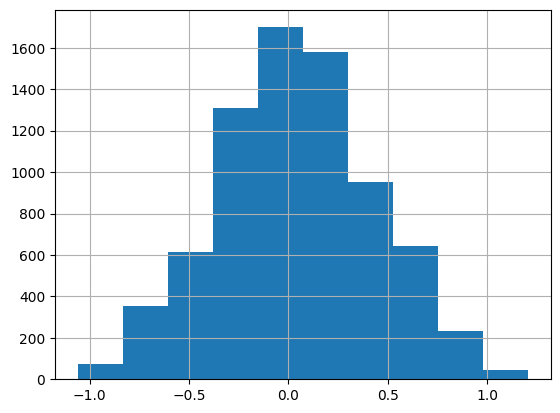

In [33]:
#visualizamos la distribución rápida de featrures
X["goals_diff"].hist()

<Axes: >

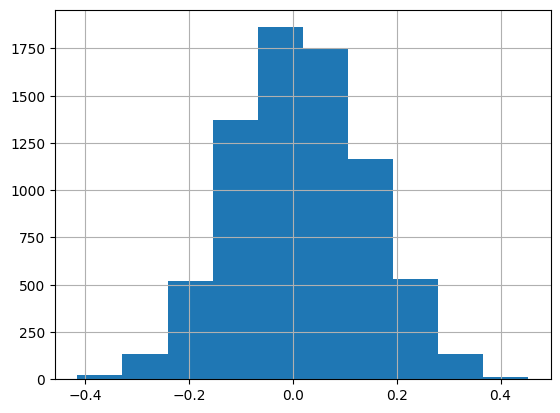

In [34]:
X["winrate_diff"].hist()

In [35]:
#importamos los modelos Logistic Regression, Random Forest y XGBoost
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, log_loss

In [36]:
#separamos los datos 80% para aprendizaje, 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
#entrenamos el modelo de regresión logística
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_lr2 = model.predict(X_test)
y_prob_lr2 = model.predict_proba(X_test)

print("Logistic regression - features")
print(classification_report(y_test, y_pred_lr2))
print(log_loss(y_test, y_prob_lr2))

Logistic regression - features
              precision    recall  f1-score   support

           0       0.54      0.84      0.66       690
           1       0.00      0.00      0.00       363
           2       0.47      0.44      0.45       448

    accuracy                           0.52      1501
   macro avg       0.34      0.43      0.37      1501
weighted avg       0.39      0.52      0.44      1501

1.0163626423505374


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
model.coef_

array([[ 1.62880255,  0.39935163, -0.2728081 , -0.18036492,  0.13493758,
         0.12983834,  0.05692815, -0.04542734],
       [ 0.27105869, -0.02718009, -0.05360139,  0.3647355 , -0.30997015,
        -0.01762505,  0.27431291,  0.05476535],
       [-1.89986124, -0.37217154,  0.32640949, -0.18437058,  0.17503257,
        -0.11221329, -0.33124106, -0.00933802]])

In [39]:
#realizamos las predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [40]:
#evaluamos
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.84      0.66       690
           1       0.00      0.00      0.00       363
           2       0.47      0.44      0.45       448

    accuracy                           0.52      1501
   macro avg       0.34      0.43      0.37      1501
weighted avg       0.39      0.52      0.44      1501



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
model.n_iter_

array([32], dtype=int32)

In [42]:
#importamos el modelo XGBoost
from xgboost import XGBClassifier

In [43]:
#entrenamos el modelo
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
#realizamos las predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

In [45]:
#Evaluamos el modelo
print(classification_report(y_test, y_pred_xgb))
print(log_loss(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.54      0.80      0.64       690
           1       0.30      0.06      0.10       363
           2       0.48      0.43      0.45       448

    accuracy                           0.51      1501
   macro avg       0.44      0.43      0.40      1501
weighted avg       0.46      0.51      0.45      1501

1.0210692230423464


In [46]:
#realizar la validación cruzada
from sklearn.model_selection import cross_val_score

In [47]:
#validación a la regresión logistica
cv_scores_lr = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [48]:
print("Logistic Regression - Validación Cruzada:")
print(cv_scores_lr)

print("Average Accuracy:")
print(cv_scores_lr.mean())

Logistic Regression - Validación Cruzada:
[0.47768155 0.534      0.528      0.50666667 0.50733333]
Average Accuracy:
0.5107363091272485


In [49]:
#Validacipion al XGBoost
cv_scores_xgb = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [50]:
print("XGBoost - Validación cruzada:")
print(cv_scores_xgb)

print("Average Accuracy:")
print(cv_scores_xgb.mean())

XGBoost - Validación cruzada:
[0.4823451  0.51       0.51733333 0.50066667 0.50666667]
Average Accuracy:
0.5034023539862315


In [51]:
#simulación Monte Carlo
teams = list(worldcup_teams)

#Creamos un prtido
import random
import numpy as np

def simulate_match(team1, team2):
  winrate_diff=(
      team_stats[team1]["winrate"] -
      team_stats[team2]["winrate"]
  )

  goals_diff = (
      team_stats[team1]["avg_goals"] -
      team_stats[team2]["avg_goals"]
  )

  features = pd.DataFrame([{
        "winrate_diff": winrate_diff,
        "goals_diff": goals_diff,
        "neutral": 1,
        "abs_winrate_diff": abs(winrate_diff),
        "abs_goals_diff": abs(goals_diff),
        "home_stronger": int(winrate_diff > 0),
        "strength_combined": winrate_diff * goals_diff,
        "match_balance": (
            abs(winrate_diff) + abs(goals_diff)
        )
    }])

  #probabilidades del modelo
  probs = model.predict_proba(features)[0]

  #Elegimos resultado aleatorio
  outcome = np.random.choice(
        [0, 1, 2],
        p=probs
    )

#devolvemos al ganador
  if outcome == 0:
    return team1
  elif outcome == 2:
    return team2
  else:
    return random.choice([team1, team2])


In [52]:
 #probamos un partido
simulate_match("Argentina", "Brazil")

'Brazil'

In [53]:
#simulamos todo el torneo para sacar las probabilidades del campeon
#simulamos la primera ronda, tenemos 48 equipos, de los cuales saldran 24 ganadores
#segunda ronda, entran 24 equipos, salen 12 ganadores
#tercera ronda, 12 equipos, 8 ganadores
#cuartos de final 8 equpos, 4 ganadores
#semi final 4 equipos, 2 ganadores
#Final 2 equipos, 1 ganador

def simulate_tournament(teams):

    teams = teams.copy()

    random.shuffle(teams)

    while len(teams) > 1:

        if len(teams) % 2 == 1:
            teams.append(random.choice(teams))

        winners = []

        for i in range(0, len(teams), 2):

            team1 = teams[i]
            team2 = teams[i + 1]

            winner = simulate_match(team1, team2)

            winners.append(winner)

        teams = winners

    return teams[0]

In [54]:
#probamos un torneo
simulate_tournament(teams)

'Colombia'

In [55]:
#Simulamos 10000 mundiales
champions = []

for i in range(10000):

    champion = simulate_tournament(teams)

    champions.append(champion)

In [56]:
#contamos los campeones
from collections import Counter

results = Counter(champions)

In [57]:
#vemos el top 10 de campeones
results.most_common(10)

[('Brazil', 1454),
 ('Germany', 1142),
 ('Spain', 818),
 ('England', 816),
 ('Argentina', 732),
 ('France', 487),
 ('Netherlands', 487),
 ('Mexico', 376),
 ('Austria', 324),
 ('Sweden', 317)]

In [59]:
#convertimos en probabilidades
for team, wins in results.most_common(10):

    probability = wins / 10000

    print(team, round(probability * 100, 2), "%")

Brazil 14.54 %
Germany 11.42 %
Spain 8.18 %
England 8.16 %
Argentina 7.32 %
France 4.87 %
Netherlands 4.87 %
Mexico 3.76 %
Austria 3.24 %
Sweden 3.17 %
